In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


In [2]:
#load dataset

df = pd.read_csv('/content/train_u6lujuX_CVtuZ9i.csv')

print(df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [3]:
print(df.shape)

(614, 13)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None


In [5]:
print(df.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [6]:
#data cleaning

df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0],inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0],inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(),inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)


/tmp/ipykernel_353/381381069.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_353/381381069.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [7]:
print(df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


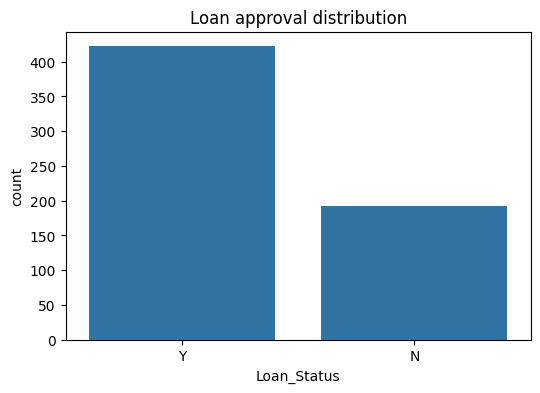

In [8]:
#EDA

#loan status
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)
plt.title('Loan approval distribution')
plt.show()

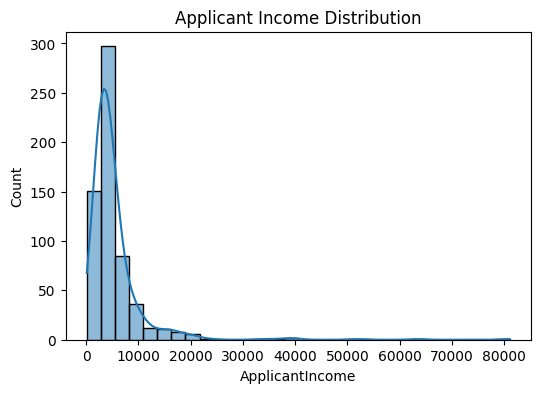

In [9]:
#income distribution

plt.figure(figsize=(6,4))
sns.histplot(df['ApplicantIncome'], bins=30, kde=True)
plt.title('Applicant Income Distribution')
plt.show()

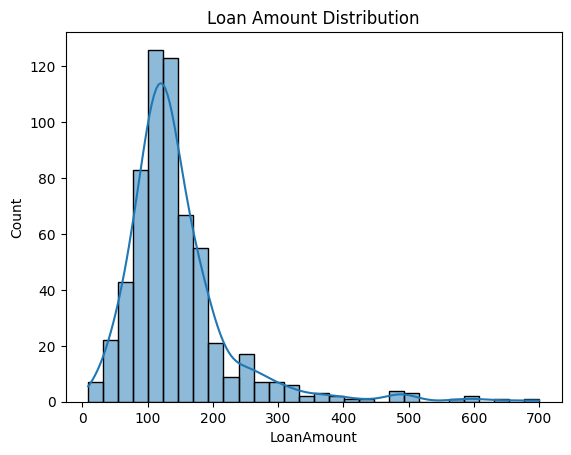

In [10]:
sns.histplot(df['LoanAmount'], bins=30, kde=True)
plt.title('Loan Amount Distribution')
plt.show()

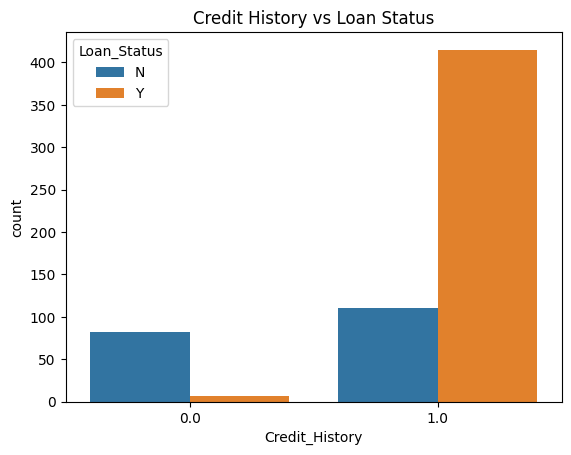

In [11]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title('Credit History vs Loan Status')
plt.show()

In [12]:
df.drop('Loan_ID', axis=1, inplace=True)

In [13]:
#label encoding

encoder = LabelEncoder()

for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = encoder.fit_transform(df[col])

In [14]:
#features and target

x = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [15]:
#Train Test Split

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.20, random_state=42)

print("\nTraining shape : ",x_train.shape)
print("\nTesting shape : ",x_test.shape)


Training shape :  (491, 11)

Testing shape :  (123, 11)


In [16]:
#STANDARDIZATION FOR KNN

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [20]:
#KNN MODEL

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(x_train_scaled, y_train)

knn_pred = knn.predict(x_test_scaled)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("\nKNN Accuracy")
print(knn_accuracy)

print("\nKNN Classification Report")
print(classification_report(y_test,knn_pred))




KNN Accuracy
0.7560975609756098

KNN Classification Report
              precision    recall  f1-score   support

           0       0.81      0.40      0.53        43
           1       0.75      0.95      0.84        80

    accuracy                           0.76       123
   macro avg       0.78      0.67      0.68       123
weighted avg       0.77      0.76      0.73       123



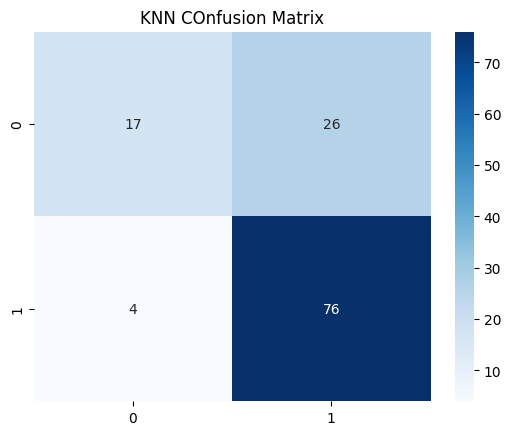

In [21]:
#KNN Confusion Matrix

knn_cm = confusion_matrix(y_test, knn_pred)

sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Blues')
plt.title("KNN COnfusion Matrix")
plt.show()

In [26]:
#DECISION TREE MODEL

dt=DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)

dt.fit(x_train,y_train)

dt_pred=dt.predict(x_test)

dt_accuracy=accuracy_score(y_test,dt_pred)

print("Decision Tree accuracy :", dt_accuracy)

print("\nDecision Tree Classification Report")
print(classification_report(y_test,dt_pred))

Decision Tree accuracy : 0.7479674796747967

Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.73      0.44      0.55        43
           1       0.75      0.91      0.82        80

    accuracy                           0.75       123
   macro avg       0.74      0.68      0.69       123
weighted avg       0.74      0.75      0.73       123



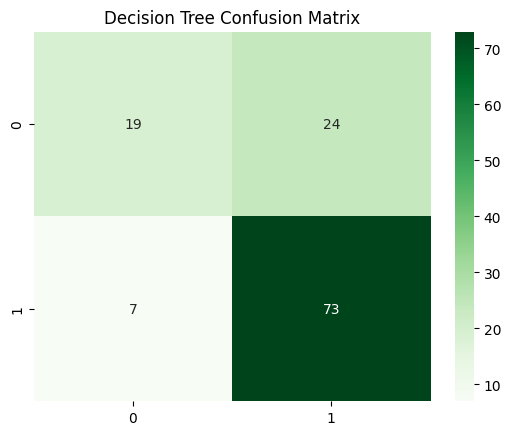

In [27]:
#Decision Tree Confusion Matrix

dt_cm = confusion_matrix(y_test, dt_pred)

sns.heatmap(dt_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [28]:
#MODEL COMPARISON

comparison = pd.DataFrame({'Model':['KNN','Decison Tree'],'Accuracy':[knn_accuracy,dt_accuracy]})
comparison

,Model,Accuracy
0,KNN,0.756098
1,Decison Tree,0.747967


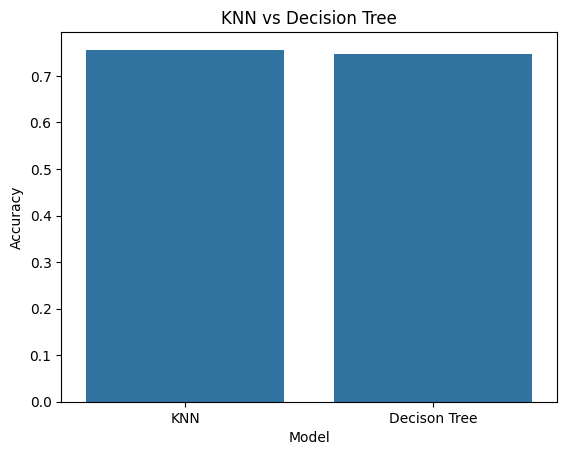

In [31]:
sns.barplot(x='Model', y='Accuracy', data=comparison)
plt.title("KNN vs Decision Tree")
plt.show()

In [36]:
#FEATURE IMPORTANCE

importance = pd.DataFrame({'feature':x.columns, 'importance':dt.feature_importances_})
importance = importance.sort_values('importance', ascending=False)
importance


,feature,importance
9,Credit_History,0.672785
7,LoanAmount,0.094993
5,ApplicantIncome,0.089552
6,CoapplicantIncome,0.074692
8,Loan_Amount_Term,0.035999
10,Property_Area,0.031979
0,Gender,0.000000
2,Dependents,0.000000
1,Married,0.000000
3,Education,0.000000


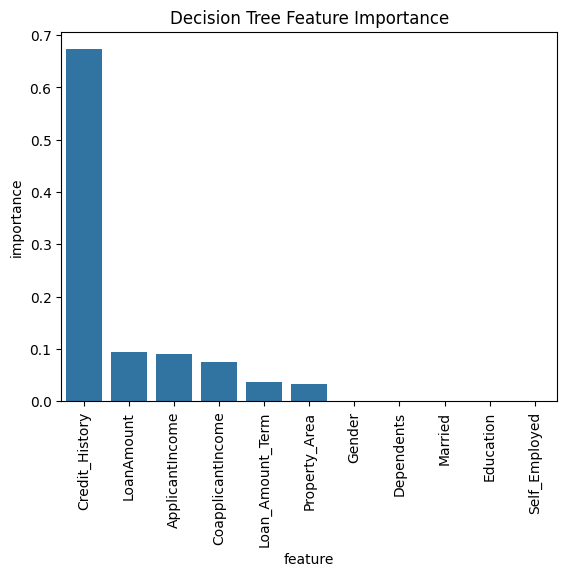

In [39]:
sns.barplot(x='feature',y='importance', data=importance)
plt.title("Decision Tree Feature Importance")
plt.xticks(rotation=90)
plt.show()

In [41]:
#PREDICT NEW APPLICANT

sample = [[
    1,      # Gender
    1,      # Married
    0,      # Dependents
    1,      # Education
    0,      # Self_Employed
    6000,   # ApplicantIncome
    2000,   # CoapplicantIncome
    150,    # LoanAmount
    360,    # Loan_Amount_Term
    1,      # Credit_History
    2       # Property_Area
]]

In [42]:
#KNN Prediction

sample_scaled = scaler.transform(sample)
knn_result = knn.predict(sample_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [43]:
#Decision Tree Prediction

dt_result = dt.predict(sample)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [45]:
print("\nKNN Prediction")
print("Approved" if knn_result == 1 else "Rejected")
print("\nDecision Tree Prediction")
print("Approved" if dt_result == 1 else "Rejected")


KNN Prediction
Approved

Decision Tree Prediction
Approved
